# Unit14 統計分析 | Statistical Analysis with scipy.stats

本 Notebook 示範如何以 Python（`scipy.stats`）進行化工程序數據的統計分析，涵蓋描述統計、機率分布、信賴區間、假設檢定與相關回歸分析。

## 學習目標
- 使用 `scipy.stats.describe()` 進行描述統計，解讀偏態與峰態
- 操作 `scipy.stats` 分布物件（`norm`、`t`、`f`、`chi2`、`weibull_min`），計算 PDF/CDF/PPF
- 使用 Shapiro-Wilk 等方法判斷數據常態性，並繪製 Q-Q 圖
- 計算母體均值與變異數之信賴區間
- 執行 t 檢定、ANOVA、卡方檢定及無母數檢定，並解讀 p 值
- 計算 Pearson/Spearman 相關係數，進行含統計推論之簡單線性回歸

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit14_Statistics'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit14'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit14
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Statistics
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Statistics\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy, matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 描述統計與數據摘要

描述統計用於摘要數據集的基本特性，包含集中趨勢、離散程度及形狀量度。

In [3]:
# ====================================================
# 2.1 描述統計示範 — 化工製程溫度數據
# ====================================================
np.random.seed(42)

# 模擬化工反應器出口溫度數據 (°C)
# 真實均值 350°C，標準差 5°C，輕微右偏
reactor_temps = np.concatenate([
    np.random.normal(350, 4, 80),
    np.random.normal(360, 3, 15),   # 少數高溫事件
    np.array([375, 378])            # 離群值
])
np.random.shuffle(reactor_temps)

n = len(reactor_temps)
print(f"樣本數: {n}")
print(f"\n【集中趨勢】")
print(f"  平均值 (mean):    {np.mean(reactor_temps):.3f} °C")
print(f"  中位數 (median):  {np.median(reactor_temps):.3f} °C")
print(f"  眾數 (mode):      {stats.mode(reactor_temps, keepdims=True).mode[0]:.3f} °C")

print(f"\n【離散程度】")
print(f"  樣本標準差 s:     {np.std(reactor_temps, ddof=1):.3f} °C")
print(f"  樣本變異數 s²:    {np.var(reactor_temps, ddof=1):.3f} °C²")
q1 = np.percentile(reactor_temps, 25)
q3 = np.percentile(reactor_temps, 75)
print(f"  Q1:               {q1:.3f} °C")
print(f"  Q3:               {q3:.3f} °C")
print(f"  IQR:              {q3 - q1:.3f} °C")
print(f"  全距 (range):     {reactor_temps.max() - reactor_temps.min():.3f} °C")

print(f"\n【形狀量度】")
print(f"  偏態係數 g1:      {stats.skew(reactor_temps):.4f}  (>0 右偏)")
print(f"  峰態係數 g2:      {stats.kurtosis(reactor_temps):.4f}  (excess, 常態=0)")

print(f"\n【scipy.stats.describe() 一次輸出】")
desc = stats.describe(reactor_temps)
print(f"  {desc}")

樣本數: 97

【集中趨勢】
  平均值 (mean):    351.705 °C
  中位數 (median):  350.685 °C
  眾數 (mode):      339.521 °C

【離散程度】
  樣本標準差 s:     6.378 °C
  樣本變異數 s²:    40.684 °C²
  Q1:               347.822 °C
  Q3:               354.228 °C
  IQR:              6.406 °C
  全距 (range):     38.479 °C

【形狀量度】
  偏態係數 g1:      1.2965  (>0 右偏)
  峰態係數 g2:      3.1324  (excess, 常態=0)

【scipy.stats.describe() 一次輸出】
  DescribeResult(nobs=97, minmax=(339.521019583641, 378.0), mean=351.7046007410123, variance=40.683522901003144, skewness=1.296486650130506, kurtosis=3.132350461602331)


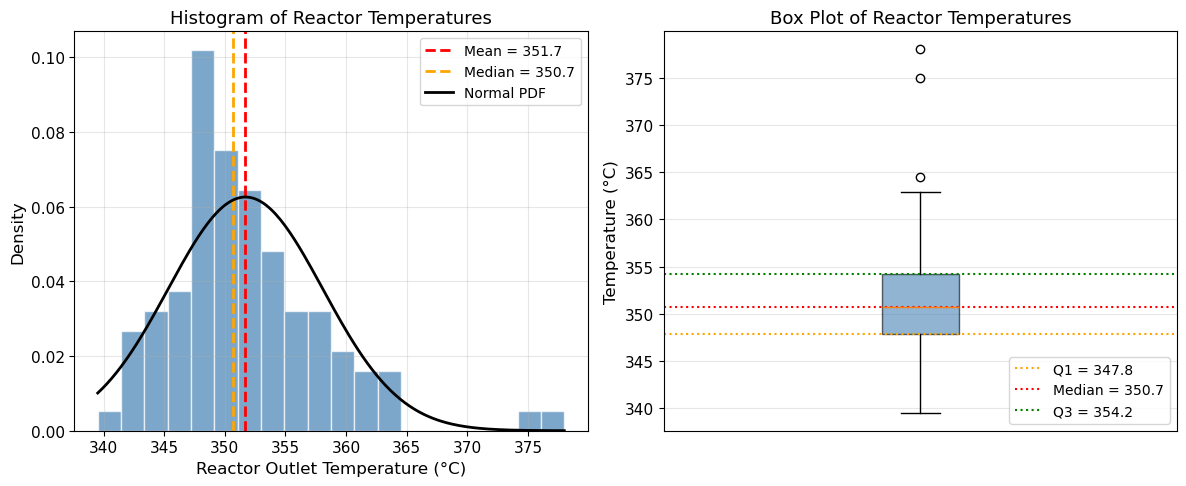

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Statistics\figs\descriptive_stats.png


In [16]:
# ====================================================
# 2.2 視覺化：直方圖 + 箱型圖
# ====================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 直方圖
ax = axes[0]
ax.hist(reactor_temps, bins=20, color='steelblue', alpha=0.7,
        edgecolor='white', density=True)
ax.axvline(np.mean(reactor_temps),  color='red',    ls='--', lw=2, label=f'Mean = {np.mean(reactor_temps):.1f}')
ax.axvline(np.median(reactor_temps), color='orange', ls='--', lw=2, label=f'Median = {np.median(reactor_temps):.1f}')

# 疊加常態曲線
x_range = np.linspace(reactor_temps.min(), reactor_temps.max(), 200)
pdf = stats.norm.pdf(x_range, np.mean(reactor_temps), np.std(reactor_temps, ddof=1))
ax.plot(x_range, pdf, 'k-', lw=2, label='Normal PDF')

ax.set_xlabel('Reactor Outlet Temperature (°C)')
ax.set_ylabel('Density')
ax.set_title('Histogram of Reactor Temperatures')
ax.legend()

# 箱型圖
ax2 = axes[1]
bp = ax2.boxplot(reactor_temps, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.6))

# 標註四分位數
ax2.axhline(q1, color='orange', ls=':', lw=1.5, label=f'Q1 = {q1:.1f}')
ax2.axhline(np.median(reactor_temps), color='red', ls=':', lw=1.5,
            label=f'Median = {np.median(reactor_temps):.1f}')
ax2.axhline(q3, color='green', ls=':', lw=1.5, label=f'Q3 = {q3:.1f}')

ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Box Plot of Reactor Temperatures')
ax2.set_xticks([])          # remove default "1" tick label
ax2.legend(loc='lower right')

plt.tight_layout()
fig_path = FIG_DIR / 'descriptive_stats.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {fig_path}")


---
### 3. 機率分布物件與常用分布

`scipy.stats` 提供統一的分布物件介面，可計算 PDF、CDF、PPF，並進行參數擬合。

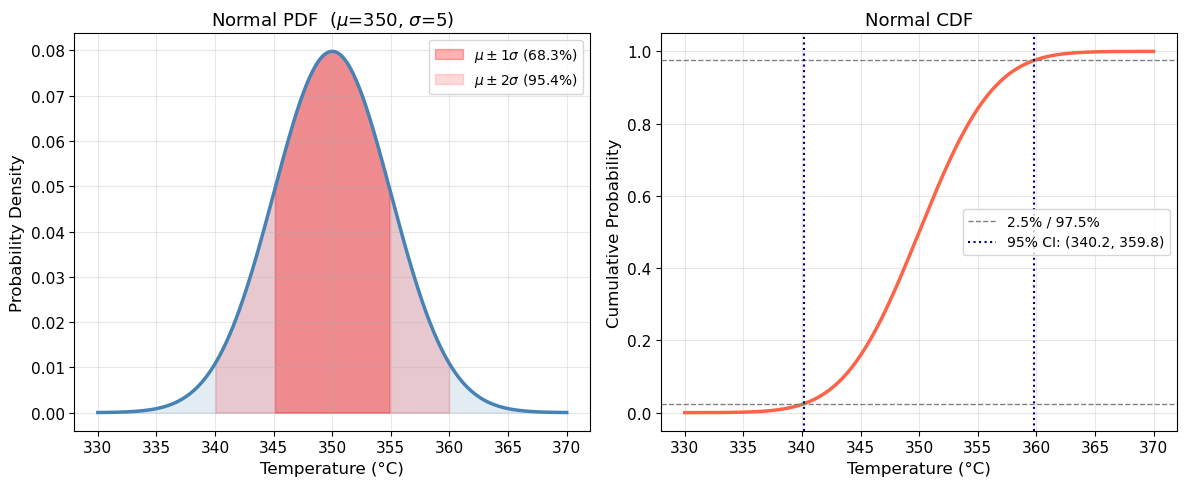

P(T ≤ 360) = 0.9772
P(T > 355) = 0.1587
95% 中央區間: (340.2001800772997, 359.7998199227003)
z_0.975 = 1.9600


In [5]:
# ====================================================
# 3.1 常態分布示範
# ====================================================
mu, sigma = 350, 5    # 反應器溫度均值與標準差
norm_dist = stats.norm(loc=mu, scale=sigma)

x = np.linspace(330, 370, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PDF
ax = axes[0]
ax.plot(x, norm_dist.pdf(x), 'steelblue', lw=2.5)
ax.fill_between(x, norm_dist.pdf(x), alpha=0.15, color='steelblue')
# 標記 ±1σ, ±2σ 區域
for k, alpha_shade in [(1, 0.3), (2, 0.15)]:
    ax.fill_between(
        x, norm_dist.pdf(x),
        where=(x >= mu - k*sigma) & (x <= mu + k*sigma),
        alpha=alpha_shade, color='red',
        label=f'$\\mu \\pm {k}\\sigma$ ({norm_dist.cdf(mu+k*sigma)-norm_dist.cdf(mu-k*sigma):.1%})'
    )
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Probability Density')
ax.set_title(f'Normal PDF  ($\\mu$={mu}, $\\sigma$={sigma})')
ax.legend()

# CDF
ax2 = axes[1]
ax2.plot(x, norm_dist.cdf(x), 'tomato', lw=2.5)
ax2.axhline(0.025, color='gray', ls='--', lw=1, label='2.5% / 97.5%')
ax2.axhline(0.975, color='gray', ls='--', lw=1)
lower, upper = norm_dist.interval(0.95)
ax2.axvline(lower, color='navy', ls=':', lw=1.5, label=f'95% CI: ({lower:.1f}, {upper:.1f})')
ax2.axvline(upper, color='navy', ls=':', lw=1.5)
ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Normal CDF')
ax2.legend()

plt.tight_layout()
fig_path = FIG_DIR / 'normal_distribution.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"P(T ≤ 360) = {norm_dist.cdf(360):.4f}")
print(f"P(T > 355) = {norm_dist.sf(355):.4f}")
print(f"95% 中央區間: {norm_dist.interval(0.95)}")
print(f"z_0.975 = {stats.norm.ppf(0.975):.4f}")

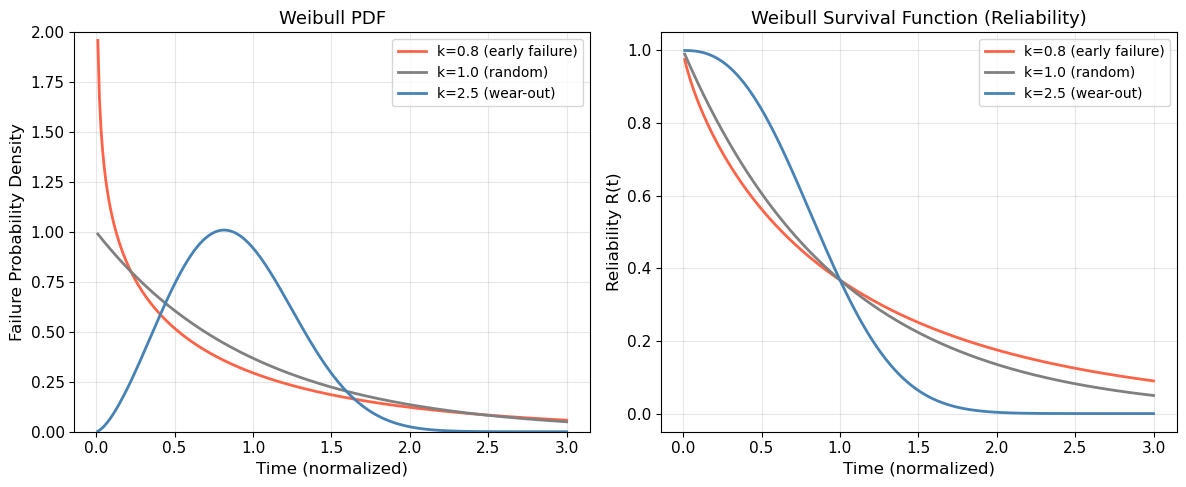

真實參數: k=2.5, scale=1000
MLE 擬合: k=2.919, scale=1101.0


In [6]:
# ====================================================
# 3.2 Weibull 分布：化工設備可靠度分析
# ====================================================
# 三種形狀參數比較
k_values = [0.8, 1.0, 2.5]
colors    = ['tomato', 'gray', 'steelblue']
labels    = ['k=0.8 (early failure)', 'k=1.0 (random)', 'k=2.5 (wear-out)']

t = np.linspace(0.01, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for k, color, label in zip(k_values, colors, labels):
    dist = stats.weibull_min(c=k, scale=1.0)
    axes[0].plot(t, dist.pdf(t), color=color, lw=2, label=label)
    axes[1].plot(t, dist.sf(t),  color=color, lw=2, label=label)

axes[0].set_xlabel('Time (normalized)')
axes[0].set_ylabel('Failure Probability Density')
axes[0].set_title('Weibull PDF')
axes[0].legend()
axes[0].set_ylim(0, 2)

axes[1].set_xlabel('Time (normalized)')
axes[1].set_ylabel('Reliability R(t)')
axes[1].set_title('Weibull Survival Function (Reliability)')
axes[1].legend()

plt.tight_layout()
fig_path = FIG_DIR / 'weibull_reliability.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# MLE 擬合示範
np.random.seed(0)
failure_times = stats.weibull_min.rvs(c=2.5, scale=1000, size=30)
c_fit, loc_fit, scale_fit = stats.weibull_min.fit(failure_times, floc=0)
print(f"真實參數: k=2.5, scale=1000")
print(f"MLE 擬合: k={c_fit:.3f}, scale={scale_fit:.1f}")

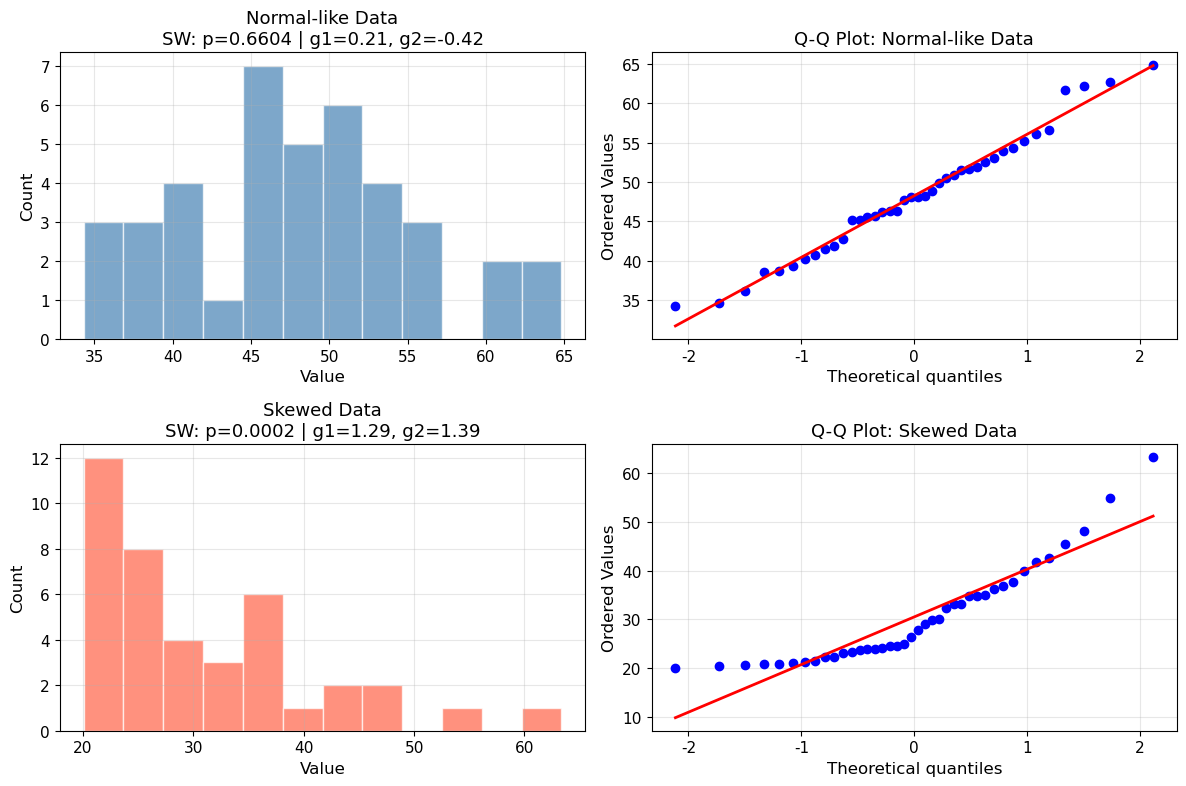


Normal-like:
  Shapiro-Wilk: W=0.9792, p=0.6604  → 符合常態
  D'Agostino:   stat=0.4692, p=0.7909

Skewed:
  Shapiro-Wilk: W=0.8623, p=0.0002  → 不符合常態
  D'Agostino:   stat=13.7535, p=0.0010


In [7]:
# ====================================================
# 3.3 常態性檢定 + Q-Q 圖
# ====================================================
np.random.seed(42)

# 兩組數據：一組近常態、一組非常態
data_normal  = np.random.normal(50, 8, 40)
data_skewed  = np.random.exponential(scale=10, size=40) + 20

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, (data, label) in enumerate([(data_normal, 'Normal-like Data'),
                                      (data_skewed,  'Skewed Data')]):
    # 直方圖
    ax = axes[idx, 0]
    ax.hist(data, bins=12, color='steelblue' if idx == 0 else 'tomato',
            alpha=0.7, edgecolor='white')
    ax.set_title(f'Histogram: {label}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

    # Shapiro-Wilk 檢定
    sw_stat, sw_p = stats.shapiro(data)
    # D'Agostino-Pearson 檢定
    dp_stat, dp_p = stats.normaltest(data)
    g1 = stats.skew(data)
    g2 = stats.kurtosis(data)
    ax.set_title(f'{label}\nSW: p={sw_p:.4f} | g1={g1:.2f}, g2={g2:.2f}')

    # Q-Q 圖
    ax2 = axes[idx, 1]
    stats.probplot(data, dist='norm', plot=ax2)
    ax2.set_title(f'Q-Q Plot: {label}')

plt.tight_layout()
fig_path = FIG_DIR / 'normality_test.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
for data, label in [(data_normal, 'Normal-like'), (data_skewed, 'Skewed')]:
    sw_stat, sw_p = stats.shapiro(data)
    dp_stat, dp_p = stats.normaltest(data)
    conclusion = "符合常態" if sw_p > 0.05 else "不符合常態"
    print(f"\n{label}:")
    print(f"  Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.4f}  → {conclusion}")
    print(f"  D'Agostino:   stat={dp_stat:.4f}, p={dp_p:.4f}")

---
### 4. 信賴區間

信賴區間提供母體參數（均值、變異數）的估計範圍，量化量測結果的不確定性。

In [8]:
# ====================================================
# 4.1 化工應用：純度量測之信賴區間計算
# ====================================================
# 某批次化工產品純度量測數據 (%)
purity_data = np.array([98.5, 99.2, 100.1, 98.8, 99.5, 100.3, 99.7, 100.0,
                         99.1, 98.9, 99.8, 99.4, 100.2, 98.7, 99.6])
n      = len(purity_data)
x_bar  = np.mean(purity_data)
s      = np.std(purity_data, ddof=1)

print(f"樣本量: n = {n}")
print(f"樣本均值: x̄ = {x_bar:.4f}%")
print(f"樣本標準差: s = {s:.4f}%")
print()

# 不同信賴水準的均值信賴區間
for confidence in [0.90, 0.95, 0.99]:
    ci = stats.t.interval(confidence, df=n-1, loc=x_bar, scale=s/np.sqrt(n))
    t_crit = stats.t.ppf(1-(1-confidence)/2, df=n-1)
    margin = t_crit * s / np.sqrt(n)
    print(f"  {confidence*100:.0f}% CI: ({ci[0]:.4f}, {ci[1]:.4f})  "
          f"± {margin:.4f}%   [t_crit = {t_crit:.4f}]")

print()
# 變異數信賴區間 (卡方分布)
alpha = 0.05
s2         = s**2
chi2_lo    = stats.chi2.ppf(alpha/2, df=n-1)
chi2_hi    = stats.chi2.ppf(1-alpha/2, df=n-1)
var_ci_lo  = (n-1)*s2 / chi2_hi
var_ci_hi  = (n-1)*s2 / chi2_lo
print(f"95% 變異數信賴區間: ({var_ci_lo:.4f}, {var_ci_hi:.4f}) %²")
print(f"95% 標準差信賴區間: ({np.sqrt(var_ci_lo):.4f}, {np.sqrt(var_ci_hi):.4f}) %")

樣本量: n = 15
樣本均值: x̄ = 99.4533%
樣本標準差: s = 0.5730%

  90% CI: (99.1927, 99.7139)  ± 0.2606%   [t_crit = 1.7613]
  95% CI: (99.1360, 99.7707)  ± 0.3173%   [t_crit = 2.1448]
  99% CI: (99.0129, 99.8938)  ± 0.4405%   [t_crit = 2.9768]

95% 變異數信賴區間: (0.1760, 0.8168) %²
95% 標準差信賴區間: (0.4195, 0.9037) %


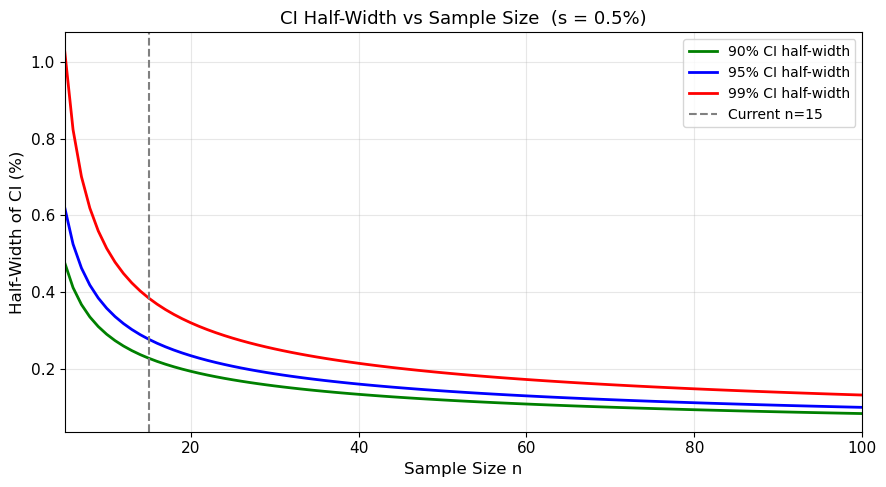

樣本數需翻 4 倍，CI 寬度才能縮減至一半（∝ 1/√n 關係）


In [9]:
# ====================================================
# 4.2 視覺化：信賴區間寬度 vs 樣本數
# ====================================================
sample_sizes = np.arange(5, 101, 1)
s_assumed = 0.5  # 假設標準差固定

ci_90_half = [stats.t.ppf(0.95, df=n-1) * s_assumed / np.sqrt(n) for n in sample_sizes]
ci_95_half = [stats.t.ppf(0.975, df=n-1) * s_assumed / np.sqrt(n) for n in sample_sizes]
ci_99_half = [stats.t.ppf(0.995, df=n-1) * s_assumed / np.sqrt(n) for n in sample_sizes]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sample_sizes, ci_90_half, 'g-',  lw=2, label='90% CI half-width')
ax.plot(sample_sizes, ci_95_half, 'b-',  lw=2, label='95% CI half-width')
ax.plot(sample_sizes, ci_99_half, 'r-',  lw=2, label='99% CI half-width')
ax.axvline(n, color='gray', ls='--', lw=1.5, label=f'Current n={n}')

ax.set_xlabel('Sample Size n')
ax.set_ylabel('Half-Width of CI (%)')
ax.set_title('CI Half-Width vs Sample Size  (s = 0.5%)')
ax.legend()
ax.set_xlim(5, 100)

plt.tight_layout()
fig_path = FIG_DIR / 'ci_vs_samplesize.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("樣本數需翻 4 倍，CI 寬度才能縮減至一半（∝ 1/√n 關係）")

---
### 5. 假設檢定

假設檢定是根據樣本數據對母體特性做出統計推論的方法。  
決策準則：若 $p < \alpha$ (通常取 0.05)，則拒絕 $H_0$


In [10]:
# ====================================================
# 5.1 單樣本 t 檢定
# 化工問題：產品純度是否符合規格（目標 99.5%）
# ====================================================
purity_spec = 99.5   # 規格目標值

t_stat, p_value = stats.ttest_1samp(purity_data, popmean=purity_spec)

print("【單樣本 t 檢定】")
print(f"  H0: μ = {purity_spec}%  (符合規格)")
print(f"  H1: μ ≠ {purity_spec}%  (不符合規格)")
print()
print(f"  樣本均值:     x̄ = {np.mean(purity_data):.4f}%")
print(f"  t 統計量:     t = {t_stat:.4f}")
print(f"  p 值 (雙尾): p = {p_value:.4f}")
print()

if p_value < 0.05:
    print("  結論: 拒絕 H0 (p < 0.05) — 產品純度與規格有顯著差異")
else:
    print("  結論: 無法拒絕 H0 (p ≥ 0.05) — 產品純度符合規格")

# 單尾檢定 (H1: μ > 99.5, 是否超規格?)
p_upper = p_value / 2 if t_stat > 0 else 1 - p_value / 2
print(f"\n  單尾 p 值 (H1: μ > {purity_spec}): p = {p_upper:.4f}")

【單樣本 t 檢定】
  H0: μ = 99.5%  (符合規格)
  H1: μ ≠ 99.5%  (不符合規格)

  樣本均值:     x̄ = 99.4533%
  t 統計量:     t = -0.3154
  p 值 (雙尾): p = 0.7571

  結論: 無法拒絕 H0 (p ≥ 0.05) — 產品純度符合規格

  單尾 p 值 (H1: μ > 99.5): p = 0.6214


In [11]:
# ====================================================
# 5.2 獨立兩樣本 t 檢定
# 化工問題：比較兩種催化劑（Cat-A vs Cat-B）的反應轉化率
# ====================================================
np.random.seed(5)
conv_A = np.random.normal(85.0, 2.5, 12)   # 催化劑 A
conv_B = np.random.normal(87.5, 2.5, 12)   # 催化劑 B

print("【獨立兩樣本 t 檢定：催化劑轉化率比較】")
print(f"  催化劑 A: n={len(conv_A)}, mean={np.mean(conv_A):.2f}%, sd={np.std(conv_A, ddof=1):.2f}%")
print(f"  催化劑 B: n={len(conv_B)}, mean={np.mean(conv_B):.2f}%, sd={np.std(conv_B, ddof=1):.2f}%")
print()

# 先進行變異數齊一性檢定
lev_stat, lev_p = stats.levene(conv_A, conv_B)
print(f"  Levene 等變異數檢定: stat={lev_stat:.4f}, p={lev_p:.4f}")
equal_var = lev_p > 0.05
print(f"  → {'等變異數 (Pooled)' if equal_var else '不等變異數 (Welch)'} t 檢定")
print()

# Welch's t-test
t_w, p_w = stats.ttest_ind(conv_A, conv_B, equal_var=False)
# Pooled t-test
t_p, p_p = stats.ttest_ind(conv_A, conv_B, equal_var=True)

print(f"  Welch's t-test: t={t_w:.4f}, p={p_w:.4f}")
print(f"  Pooled t-test:  t={t_p:.4f}, p={p_p:.4f}")
print()

conclusion = "兩種催化劑轉化率有顯著差異" if p_w < 0.05 else "兩種催化劑轉化率無顯著差異"
print(f"  結論 (Welch, α=0.05): {conclusion}")

【獨立兩樣本 t 檢定：催化劑轉化率比較】
  催化劑 A: n=12, mean=85.20%, sd=2.56%
  催化劑 B: n=12, mean=86.85%, sd=2.72%

  Levene 等變異數檢定: stat=0.2604, p=0.6149
  → 等變異數 (Pooled) t 檢定

  Welch's t-test: t=-1.5358, p=0.1389
  Pooled t-test:  t=-1.5358, p=0.1389

  結論 (Welch, α=0.05): 兩種催化劑轉化率無顯著差異


In [12]:
# ====================================================
# 5.3 單因子 ANOVA
# 化工問題：三種操作溫度對反應轉化率的影響
# ====================================================
np.random.seed(7)
temp_300 = np.random.normal(82.0, 2.5, 10)
temp_320 = np.random.normal(87.5, 2.5, 10)
temp_340 = np.random.normal(92.0, 2.5, 10)

print("【單因子 ANOVA：三種操作溫度對轉化率的影響】")
for label, data in [("300°C", temp_300), ("320°C", temp_320), ("340°C", temp_340)]:
    print(f"  {label}: mean={np.mean(data):.2f}%, sd={np.std(data, ddof=1):.2f}%")
print()

f_stat, p_value = stats.f_oneway(temp_300, temp_320, temp_340)
print(f"  F 統計量: F = {f_stat:.4f}")
print(f"  p 值:     p = {p_value:.6f}")
print()

if p_value < 0.05:
    print("  結論: 拒絕 H0 — 操作溫度對轉化率有顯著影響 (p < 0.05)")
else:
    print("  結論: 無法拒絕 H0 — 操作溫度對轉化率無顯著影響")

# 手動建立 ANOVA 表
all_data = np.concatenate([temp_300, temp_320, temp_340])
grand_mean = np.mean(all_data)
groups = [temp_300, temp_320, temp_340]
k = len(groups)
N = len(all_data)

SS_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
SS_within  = sum(np.sum((g - np.mean(g))**2) for g in groups)
SS_total   = SS_between + SS_within

df_b = k - 1
df_w = N - k
MS_b = SS_between / df_b
MS_w = SS_within  / df_w
F_manual = MS_b / MS_w

print(f"\n  ANOVA 表")
print(f"  {'來源':<15} {'SS':>10} {'df':>5} {'MS':>10} {'F':>8}")
print(f"  {'-'*55}")
print(f"  {'組間 (Between)':<15} {SS_between:>10.3f} {df_b:>5} {MS_b:>10.3f} {F_manual:>8.4f}")
print(f"  {'組內 (Within)':<15} {SS_within:>10.3f}  {df_w:>4} {MS_w:>10.3f}")
print(f"  {'總計 (Total)':<15} {SS_total:>10.3f}  {N-1:>4}")

【單因子 ANOVA：三種操作溫度對轉化率的影響】
  300°C: mean=82.19%, sd=2.40%
  320°C: mean=86.79%, sd=1.83%
  340°C: mean=91.97%, sd=3.31%

  F 統計量: F = 35.8039
  p 值:     p = 0.000000

  結論: 拒絕 H0 — 操作溫度對轉化率有顯著影響 (p < 0.05)

  ANOVA 表
  來源                      SS    df         MS        F
  -------------------------------------------------------
  組間 (Between)       479.507     2    239.754  35.8039
  組內 (Within)        180.800    27      6.696
  總計 (Total)         660.308    29


In [13]:
# ====================================================
# 5.4 卡方檢定 + 無母數檢定
# ====================================================
print("【卡方適合度檢定：反應產物分布是否符合理論比例 1:2:1】")
observed_counts = np.array([22, 48, 30])
expected_ratio   = np.array([1, 2, 1])
expected_counts  = expected_ratio / expected_ratio.sum() * observed_counts.sum()

chi2_s, p_s = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(f"  觀測:   {observed_counts}")
print(f"  期望:   {expected_counts}")
print(f"  chi2 = {chi2_s:.4f}, p = {p_s:.4f}")
if p_s < 0.05:
    print("  結論: 分布不符合理論比例 1:2:1")
else:
    print("  結論: 分布符合理論比例 1:2:1")

print()
print("【卡方獨立性檢定：操作班別 vs 產品等級是否相關】")
contingency = np.array([
    [45, 10, 5],   # 早班
    [42, 13, 5],   # 中班
    [40, 12, 8],   # 晚班
])
chi2_ind, p_ind, df_ind, expected_ind = stats.chi2_contingency(contingency)
print(f"  chi2 = {chi2_ind:.4f}, p = {p_ind:.4f}, df = {df_ind}")
if p_ind < 0.05:
    print("  結論: 班別與產品等級相關 (p < 0.05)")
else:
    print("  結論: 班別與產品等級無顯著相關")

print()
print("【Mann-Whitney U 無母數檢定（兩樣本中位數比較）】")
u_stat, p_mw = stats.mannwhitneyu(conv_A, conv_B, alternative='two-sided')
print(f"  U = {u_stat:.0f}, p = {p_mw:.4f}")

print()
print("【Kruskal-Wallis 無母數 ANOVA】")
h_stat, p_kw = stats.kruskal(temp_300, temp_320, temp_340)
print(f"  H = {h_stat:.4f}, p = {p_kw:.6f}")

【卡方適合度檢定：反應產物分布是否符合理論比例 1:2:1】
  觀測:   [22 48 30]
  期望:   [25. 50. 25.]
  chi2 = 1.4400, p = 0.4868
  結論: 分布符合理論比例 1:2:1

【卡方獨立性檢定：操作班別 vs 產品等級是否相關】
  chi2 = 1.6992, p = 0.7909, df = 4
  結論: 班別與產品等級無顯著相關

【Mann-Whitney U 無母數檢定（兩樣本中位數比較）】
  U = 42, p = 0.0885

【Kruskal-Wallis 無母數 ANOVA】
  H = 22.3510, p = 0.000014


---
### 6. 相關分析與線性回歸

Pearson/Spearman 相關係數用於量化兩變數間的關聯強度；  
`scipy.stats.linregress()` 提供簡單線性回歸並直接輸出統計推論結果（t 檢定、p 值）。

In [14]:
# ====================================================
# 6.1 相關係數分析
# 化工問題：反應溫度與轉化率的相關性
# ====================================================
temperature = np.array([260, 280, 300, 320, 340, 360, 380, 400], dtype=float)
conversion  = np.array([68.2, 74.5, 80.1, 85.3, 89.8, 93.2, 95.6, 97.1])

# 三種相關係數
r_pearson,  p_pearson  = stats.pearsonr(temperature, conversion)
rho_spear,  p_spear    = stats.spearmanr(temperature, conversion)
tau_kendall, p_kendall = stats.kendalltau(temperature, conversion)

print("【相關係數比較：反應溫度 vs 轉化率】")
print(f"  Pearson  r  = {r_pearson:.4f}  (p = {p_pearson:.6f})")
print(f"  Spearman ρ  = {rho_spear:.4f}  (p = {p_spear:.6f})")
print(f"  Kendall  τ  = {tau_kendall:.4f}  (p = {p_kendall:.6f})")
print()

strength = "極強" if abs(r_pearson) >= 0.8 else ("強" if abs(r_pearson) >= 0.6 else "中等")
direction = "正" if r_pearson > 0 else "負"
print(f"  解讀: {direction}相關，{strength}相關 (|r| = {abs(r_pearson):.4f})")

【相關係數比較：反應溫度 vs 轉化率】
  Pearson  r  = 0.9815  (p = 0.000016)
  Spearman ρ  = 1.0000  (p = 0.000000)
  Kendall  τ  = 1.0000  (p = 0.000050)

  解讀: 正相關，極強相關 (|r| = 0.9815)


【簡單線性回歸：轉化率 vs 溫度】
  迴歸模型: y = 0.2093·T + (16.41)
  相關係數  r      = 0.9815
  決定係數  R²     = 0.9634
  p 值 (斜率顯著性) = 0.000016
  斜率標準誤        = 0.016663

  斜率 95% CI: (0.1685, 0.2501)
  → 溫度每升高 1°C，轉化率平均增加 0.2093% (95% CI: 0.1685~0.2501%)


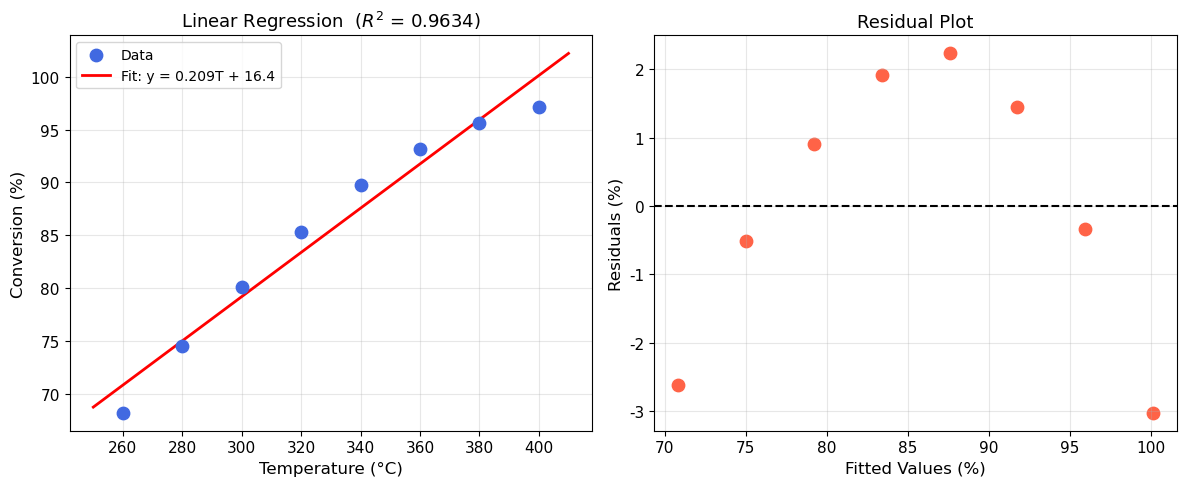

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Statistics\figs\linear_regression.png


In [15]:
# ====================================================
# 6.2 簡單線性回歸 (scipy.stats.linregress)
# ====================================================
result = stats.linregress(temperature, conversion)
n = len(temperature)
t_crit = stats.t.ppf(0.975, df=n-2)

print("【簡單線性回歸：轉化率 vs 溫度】")
print(f"  迴歸模型: y = {result.slope:.4f}·T + ({result.intercept:.2f})")
print(f"  相關係數  r      = {result.rvalue:.4f}")
print(f"  決定係數  R²     = {result.rvalue**2:.4f}")
print(f"  p 值 (斜率顯著性) = {result.pvalue:.6f}")
print(f"  斜率標準誤        = {result.stderr:.6f}")
print()

beta1_lo = result.slope - t_crit * result.stderr
beta1_hi = result.slope + t_crit * result.stderr
print(f"  斜率 95% CI: ({beta1_lo:.4f}, {beta1_hi:.4f})")
print(f"  → 溫度每升高 1°C，轉化率平均增加 {result.slope:.4f}% (95% CI: {beta1_lo:.4f}~{beta1_hi:.4f}%)")

# 預測值與殘差
y_pred  = result.slope * temperature + result.intercept
residuals = conversion - y_pred

# 視覺化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 散點圖 + 回歸線
ax = axes[0]
x_fit = np.linspace(250, 410, 100)
y_fit = result.slope * x_fit + result.intercept
ax.scatter(temperature, conversion, color='royalblue', s=80, zorder=5, label='Data')
ax.plot(x_fit, y_fit, 'r-', lw=2,
        label=f'Fit: y = {result.slope:.3f}T + {result.intercept:.1f}')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Conversion (%)')
ax.set_title(f'Linear Regression  ($R^2$ = {result.rvalue**2:.4f})')
ax.legend()

# 殘差圖
ax2 = axes[1]
ax2.scatter(y_pred, residuals, color='tomato', s=80)
ax2.axhline(0, color='k', ls='--', lw=1.5)
ax2.set_xlabel('Fitted Values (%)')
ax2.set_ylabel('Residuals (%)')
ax2.set_title('Residual Plot')

plt.tight_layout()
fig_path = FIG_DIR / 'linear_regression.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {fig_path}")

---
### 7. Python 相關函式總覽

| 功能類別 | 函式 | 說明 |
|----------|------|------|
| **描述統計** | `scipy.stats.describe(data)` | 一次輸出樣本數、最小最大值、均值、變異數、偏態、峰態 |
| | `scipy.stats.skew(data)` | 偏態係數 |
| | `scipy.stats.kurtosis(data)` | 峰態係數 (excess kurtosis) |
| **機率分布** | `scipy.stats.norm(loc, scale)` | 常態分布 |
| | `scipy.stats.t(df)` | t 分布 |
| | `scipy.stats.f(dfn, dfd)` | F 分布 |
| | `scipy.stats.chi2(df)` | 卡方分布 |
| | `scipy.stats.weibull_min(c, scale)` | Weibull 分布（可靠度分析） |
| **常態性檢定** | `scipy.stats.shapiro(data)` | Shapiro-Wilk 檢定（小樣本 n<50） |
| | `scipy.stats.normaltest(data)` | D'Agostino-Pearson 檢定（大樣本） |
| | `scipy.stats.probplot(data, plot=ax)` | Q-Q 圖 |
| **t 檢定** | `scipy.stats.ttest_1samp(a, popmean)` | 單樣本 t 檢定 |
| | `scipy.stats.ttest_ind(a, b)` | 獨立兩樣本 t 檢定 |
| | `scipy.stats.ttest_rel(a, b)` | 配對樣本 t 檢定 |
| **變異數** | `scipy.stats.levene(*groups)` | Levene 檢定（推薦） |
| | `scipy.stats.bartlett(*groups)` | Bartlett 檢定 |
| **ANOVA** | `scipy.stats.f_oneway(*groups)` | 單因子變異數分析 |
| **卡方** | `scipy.stats.chisquare(f_obs, f_exp)` | 適合度檢定 |
| | `scipy.stats.chi2_contingency(table)` | 獨立性檢定 |
| **無母數** | `scipy.stats.mannwhitneyu(a, b)` | Mann-Whitney U |
| | `scipy.stats.kruskal(*groups)` | Kruskal-Wallis |
| **相關** | `scipy.stats.pearsonr(x, y)` | Pearson 線性相關 |
| | `scipy.stats.spearmanr(x, y)` | Spearman 秩次相關 |
| **迴歸** | `scipy.stats.linregress(x, y)` | 簡單線性回歸（含統計推論）|

---
**課程資訊**  
- 課程名稱：電腦在化工上之應用 (ChemE 3502)  
- 課程單元：Unit14 統計分析  
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室  
- 授課教師：莊曜禎 助理教授  
- 更新日期：2026-03-02

**課程授權 [CC BY-NC-SA 4.0]**  
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。